In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [3]:
chunks = pd.read_csv(
    "../data/raw/complaints.csv.zip",
    compression="zip",
    chunksize=50000
)

In [4]:
sample = pd.read_csv(
    "../data/raw/complaints.csv.zip",
    compression="zip",
    nrows=5
)

print(sample.columns.tolist())
print(sample.shape)
sample.head()

['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative', 'Company public response', 'Company', 'State', 'ZIP code', 'Tags', 'Consumer consent provided?', 'Submitted via', 'Date sent to company', 'Company response to consumer', 'Timely response?', 'Consumer disputed?', 'Complaint ID']
(5, 18)


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,NaN,Experian Information Solutions Inc.,FL,32092,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195687
1,2025-06-20,Debt collection,Telecommunications debt,Attempts to collect debt not owed,Debt is not yours,NaN,Company can't verify or dispute the facts in t...,"Eastern Account Systems of Connecticut, Inc.",FL,342XX,NaN,NaN,Web,2025-06-20,Closed with explanation,Yes,NaN,14195688
2,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",AZ,85225,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195689
3,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,Experian Information Solutions Inc.,AZ,85225,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195690
4,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account status incorrect,NaN,NaN,Experian Information Solutions Inc.,IL,60628,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195692


In [5]:
import pandas as pd
from collections import Counter

In [6]:
product_counter = Counter()

chunk_size = 50000

for chunk in pd.read_csv(
    "../data/raw/complaints.csv.zip",
    compression="zip",
    usecols=["Product"],
    chunksize=chunk_size
):
    product_counter.update(chunk["Product"].dropna())

In [7]:
product_counts = pd.DataFrame(
    product_counter.items(),
    columns=["Product", "Count"]
).sort_values(
    by="Count",
    ascending=False
)

product_counts.head(20)

,Product,Count
0,Credit reporting or other personal consumer re...,4834855
12,"Credit reporting, credit repair services, or o...",2163857
1,Debt collection,799197
7,Mortgage,422254
3,Checking or savings account,291178
2,Credit card,226686
13,Credit card or prepaid card,206369
4,"Money transfer, virtual currency, or money ser...",145066
11,Credit reporting,140429
10,Student loan,109717


<Figure size 1200x600 with 0 Axes>

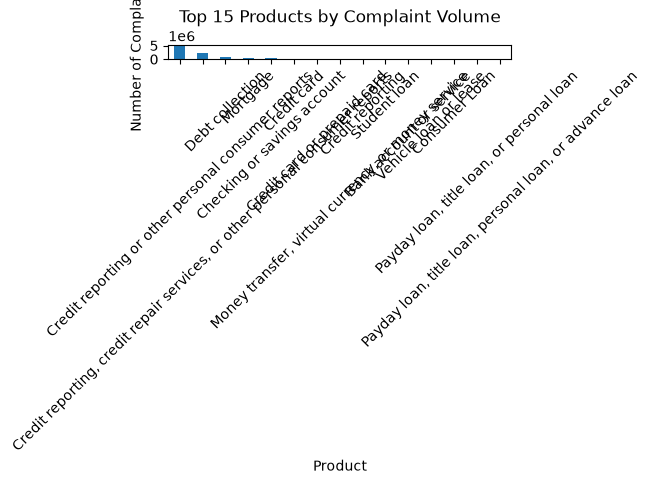

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

product_counts.head(15).plot(
    x="Product",
    y="Count",
    kind="bar",
    legend=False
)

plt.title("Top 15 Products by Complaint Volume")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [9]:
product_counts[
    product_counts["Product"].str.contains(
        "card|loan|saving|transfer",
        case=False,
        na=False
    )
]

,Product,Count
3,Checking or savings account,291178
2,Credit card,226686
13,Credit card or prepaid card,206369
4,"Money transfer, virtual currency, or money ser...",145066
10,Student loan,109717
5,Vehicle loan or lease,72957
17,Consumer Loan,31574
14,"Payday loan, title loan, or personal loan",30641
8,"Payday loan, title loan, personal loan, or adv...",16514
9,Prepaid card,15280


In [10]:
product_counts[
    product_counts["Product"].str.contains(
        "card|loan|saving|transfer",
        case=False,
        na=False
    )
]

,Product,Count
3,Checking or savings account,291178
2,Credit card,226686
13,Credit card or prepaid card,206369
4,"Money transfer, virtual currency, or money ser...",145066
10,Student loan,109717
5,Vehicle loan or lease,72957
17,Consumer Loan,31574
14,"Payday loan, title loan, or personal loan",30641
8,"Payday loan, title loan, personal loan, or adv...",16514
9,Prepaid card,15280


In [12]:
narrative_col = "Consumer complaint narrative"

with_narrative = 0
without_narrative = 0

for chunk in pd.read_csv(
    "../data/raw/complaints.csv.zip",
    compression="zip",
    usecols=[narrative_col],
    chunksize=10000
):

    with_narrative += chunk[narrative_col].notna().sum()

    without_narrative += chunk[narrative_col].isna().sum()

print(f"With narrative: {with_narrative:,}")
print(f"Without narrative: {without_narrative:,}")

With narrative: 2,980,756
Without narrative: 6,629,041


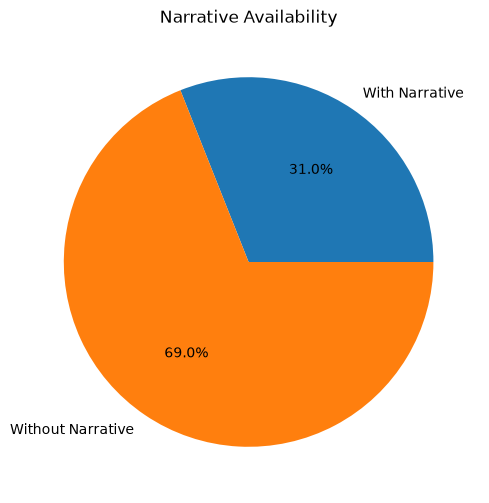

In [13]:
plt.figure(figsize=(6,6))

plt.pie(
    [with_narrative, without_narrative],
    labels=["With Narrative", "Without Narrative"],
    autopct="%1.1f%%"
)

plt.title("Narrative Availability")
plt.show()

In [16]:
word_counts = []

for chunk in pd.read_csv(
    "../data/raw/complaints.csv.zip",
    compression="zip",
    usecols=["Consumer complaint narrative"],
    chunksize=10000
):

    temp = (
        chunk["Consumer complaint narrative"]
        .dropna()
        .astype(str)
        .apply(lambda x: len(x.split()))
    )

    word_counts.extend(temp.tolist())

In [17]:
import pandas as pd

wc = pd.Series(word_counts)

wc.describe()

count    2.980756e+06
mean     1.755976e+02
std      2.259282e+02
min      1.000000e+00
25%      5.900000e+01
50%      1.140000e+02
75%      2.090000e+02
max      6.469000e+03
dtype: float64

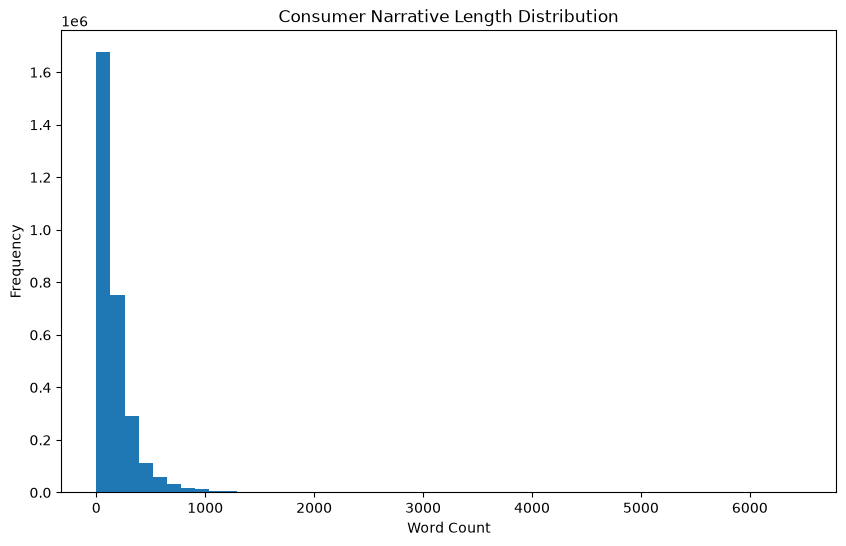

In [18]:
plt.figure(figsize=(10,6))

plt.hist(
    wc,
    bins=50
)

plt.title("Consumer Narrative Length Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")

plt.show()

In [19]:
wc.describe()

count    2.980756e+06
mean     1.755976e+02
std      2.259282e+02
min      1.000000e+00
25%      5.900000e+01
50%      1.140000e+02
75%      2.090000e+02
max      6.469000e+03
dtype: float64

In [20]:
TARGET_PRODUCTS = [
    "Credit card",
    "Checking or savings account",
    "Payday loan, title loan, or personal loan",
    "Money transfer, virtual currency, or money service"
]

In [21]:
import pandas as pd

TARGET_PRODUCTS = [
    "Credit card",
    "Checking or savings account",
    "Payday loan, title loan, or personal loan",
    "Money transfer, virtual currency, or money service"
]

In [22]:
output_file = "../data/processed/filtered_complaints.csv"

first_chunk = True

for chunk in pd.read_csv(
    "../data/raw/complaints.csv.zip",
    compression="zip",
    chunksize=50000
):

    filtered = chunk[
        chunk["Product"].isin(TARGET_PRODUCTS)
    ].copy()

    filtered = filtered[
        filtered["Consumer complaint narrative"].notna()
    ]

    filtered.to_csv(
        output_file,
        mode="w" if first_chunk else "a",
        header=first_chunk,
        index=False
    )

    first_chunk = False

print("Filtering complete.")

Filtering complete.


In [23]:
filtered_df = pd.read_csv(
    "../data/processed/filtered_complaints.csv",
    nrows=5
)

filtered_df.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2025-06-13,Credit card,Store credit card,Getting a credit card,Card opened without my consent or knowledge,A XXXX XXXX card was opened under my name by a...,Company has responded to the consumer and the ...,"CITIBANK, N.A.",TX,78230,Servicemember,Consent provided,Web,2025-06-13,Closed with non-monetary relief,Yes,NaN,14069121
1,2025-06-13,Checking or savings account,Checking account,Managing an account,Deposits and withdrawals,I made the mistake of using my wellsfargo debi...,Company has responded to the consumer and the ...,WELLS FARGO & COMPANY,ID,83815,NaN,Consent provided,Web,2025-06-13,Closed with explanation,Yes,NaN,14061897
2,2025-06-12,Credit card,General-purpose credit card or charge card,"Other features, terms, or problems",Other problem,"Dear CFPB, I have a secured credit card with c...",Company has responded to the consumer and the ...,"CITIBANK, N.A.",NY,11220,NaN,Consent provided,Web,2025-06-13,Closed with monetary relief,Yes,NaN,14047085
3,2025-06-12,Credit card,General-purpose credit card or charge card,Incorrect information on your report,Account information incorrect,I have a Citi rewards cards. The credit balanc...,Company has responded to the consumer and the ...,"CITIBANK, N.A.",IL,60067,NaN,Consent provided,Web,2025-06-12,Closed with explanation,Yes,NaN,14040217
4,2025-06-09,Credit card,General-purpose credit card or charge card,Problem with a purchase shown on your statement,Credit card company isn't resolving a dispute ...,b'I am writing to dispute the following charge...,Company has responded to the consumer and the ...,"CITIBANK, N.A.",TX,78413,Older American,Consent provided,Web,2025-06-09,Closed with monetary relief,Yes,NaN,13968411


In [24]:
import pandas as pd

count = 0

for chunk in pd.read_csv(
    "../data/processed/filtered_complaints.csv",
    chunksize=50000
):
    count += len(chunk)

print(count)

335412


In [25]:
count = 0

for chunk in pd.read_csv(
    "../data/processed/filtered_complaints.csv",
    chunksize=50000
):
    count += len(chunk)

print(f"Filtered complaints: {count:,}")

Filtered complaints: 335,412


In [26]:
import re

def clean_text(text):

    text = str(text).lower()

    boilerplate_patterns = [
        r"dear cfpb",
        r"to whom it may concern",
        r"i am writing to file a complaint",
        r"consumer financial protection bureau"
    ]

    for pattern in boilerplate_patterns:
        text = re.sub(pattern, "", text)

    text = re.sub(r"http\S+", " ", text)

    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)

    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [29]:
output_file = "../data/processed/filtered_complaints_cleaned.csv"

first_chunk = True

for chunk in pd.read_csv(
    "../data/processed/filtered_complaints.csv",
    chunksize=10000
):

    chunk["cleaned_narrative"] = (
        chunk["Consumer complaint narrative"]
        .astype(str)
        .apply(clean_text)
    )

    chunk.to_csv(
        output_file,
        mode="w" if first_chunk else "a",
        header=first_chunk,
        index=False
    )

    first_chunk = False

print("Cleaning completed.")

Cleaning completed.


In [30]:
sample = pd.read_csv(
    "../data/processed/filtered_complaints_cleaned.csv",
    nrows=5
)

sample[
    [
        "Consumer complaint narrative",
        "cleaned_narrative"
    ]
]

,Consumer complaint narrative,cleaned_narrative
0,A XXXX XXXX card was opened under my name by a...,a xxxx xxxx card was opened under my name by a...
1,I made the mistake of using my wellsfargo debi...,i made the mistake of using my wellsfargo debi...
2,"Dear CFPB, I have a secured credit card with c...",i have a secured credit card with citibank whi...
3,I have a Citi rewards cards. The credit balanc...,i have a citi rewards cards the credit balance...
4,b'I am writing to dispute the following charge...,b i am writing to dispute the following charge...
